Парная линейная регрессия
Цель работы
    Познакомиться с моделью парной линейной регрессии регрессии и методом градиентного спуска.

Содержание работы
Найти оценки параметров модели парной линейной регрессии прямыми вычислениями и палучить с помощью модели прогнозы результативного прознака.
Найти оценки параметров модели парной линейной регрессии с использованием метода градиентного спуска.
Оценить качество построенной модели, сравнив на графике обучающую выборку и прогнозы.
Построить кривые обучения.

In [62]:
#Загрузим необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
#Исходные данные: x - расходы на рекламу, Y - объемы продаж
x = np.array([3, 5, 7, 6, 9])
Y = np.array([3, 7, 11, 14, 15])
display(x, Y)

array([3, 5, 7, 6, 9])

array([ 3,  7, 11, 14, 15])

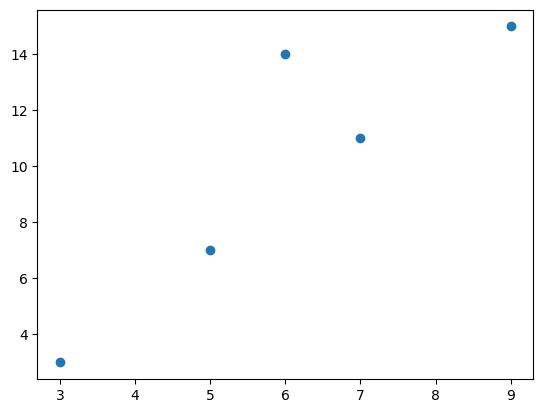

In [64]:
#Изобразим их на графике
plt.figure()
plt.scatter(x, Y)
plt.show()

In [65]:
#Вычислим оценки коэффициентов парной линейной регрессии по формулам
a1 = ((x - x.mean())*(Y - Y.mean())).mean()/((x - x.mean())**2).mean()
a0 = Y.mean() - a1*x.mean()
print("Модель линейной регрессии: Y^ = ", a0, " + ", a1, "* x")

Модель линейной регрессии: Y^ =  -2.0  +  2.0 * x


In [66]:
#Дадим серию прогнозов Y^ для x от 3 до 9 с шагом 1
x_space = np.linspace(3, 9, 7)
print(x_space)
Y_pred = a0 + a1*x_space
print(Y_pred)

[3. 4. 5. 6. 7. 8. 9.]
[ 4.  6.  8. 10. 12. 14. 16.]


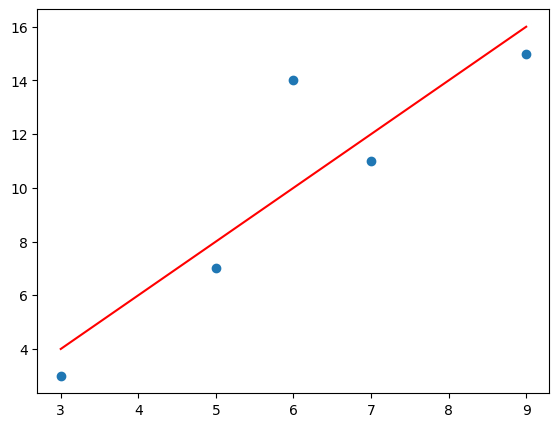

In [67]:
#Изобразим на графике исходные данные и прогнозы 
fig  = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')
#ax.scatter(x_space, Y_pred)

In [68]:
#Реализуем шаг градиентного спуска в модели парной лдинейной регрессии
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((self.predict(x)-Y)**2).mean()
    def fit(self, x, Y):
        alpha = 0.1
        dT_a0 = -2*sum((Y -self.predict(x)))
        dT_a1 = -2*sum((Y -self.predict(x))*x)
        self.a0 -= alpha*dT_a0
        self.a1 -= alpha*dT_a1

In [69]:
#Получим прогнозы до градиентного спуска с начальными значениями параметров
regr = SimpleRegression()
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print(regr.MSE(x, Y))

0
0
0
0
0
120.0


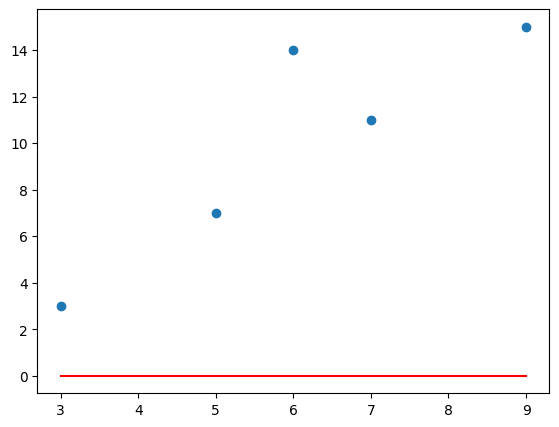

In [70]:
#Выведем прогнозы до градиентного спуска на графике
x_space = np.linspace(3, 9, 7)
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

MSE после первого шага градиентного спуска:  183892.0


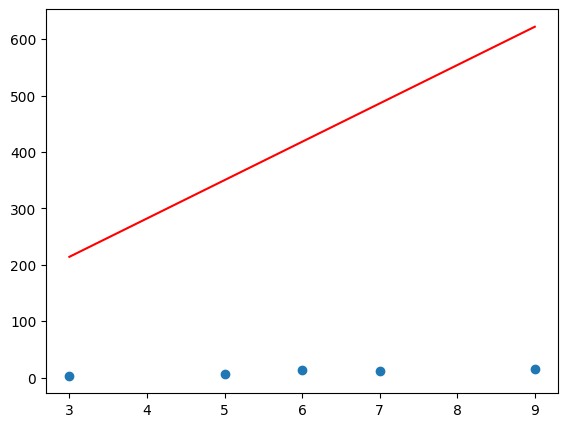

In [71]:
#Реализуем шаг градиентного спуска
regr.fit(x, Y)
print("MSE после первого шага градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

In [72]:
#Реализуем цикл градиентного спуска
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((Y - self.predict(x))**2).mean()
    def MAE(self, x, Y):
        return abs(Y - self.predict(x)).mean()
    def MAPE(self, x, Y):
        return abs((Y - self.predict(x))/Y).mean()
    def fit(self, x, Y, alpha = 0.001, epsylon = 0.01, max_steps = 5000):
        steps, errors = [], []
        step = 0
        for _ in range(max_steps):
            dT_a0 = -2*sum((Y -self.predict(x)))
            dT_a1 = -2*sum((Y -self.predict(x))*x)
            self.a0 -= alpha*dT_a0
            self.a1 -= alpha*dT_a1
            new_error = self.MSE(x, Y)
            step += 1
            steps.append(step)
            errors.append(new_error)
            if new_error < epsylon:
                break
        return steps, errors

In [73]:
#Запустим цикл градиентного спуска с заданной точностью 5
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 5)

5.004697916218
8.190462542210001
11.376227168202002
9.783344855206002
14.561991794194002
MSE после градиентного спуска:  4.709918696051655


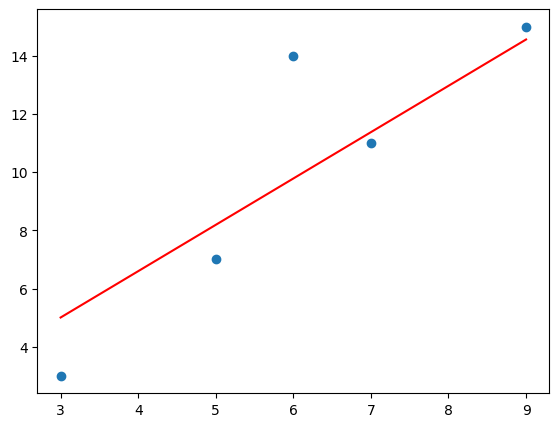

In [74]:
#Выведем график  прогнозов и вычислим MSE
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

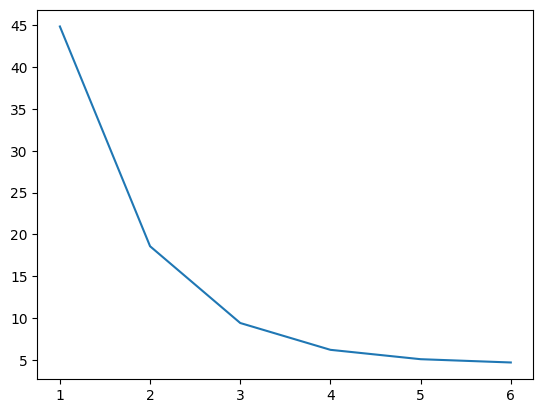

In [75]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

In [76]:
#Запустим цикл градиентного спуска с заданной точностью 0.05
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 0.05)

MSE после градиентного спуска:  4.000028517306817


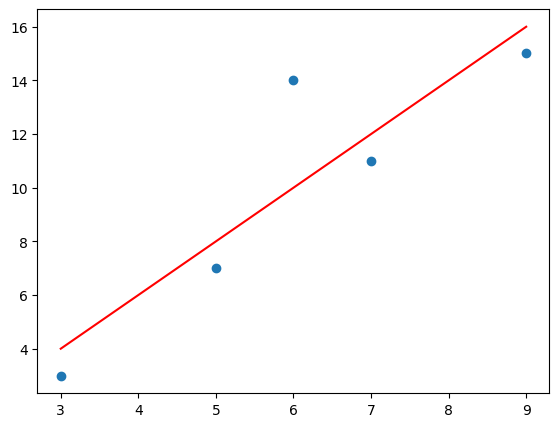

In [77]:
#Выведем график прогнозов и вычислим MSE
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

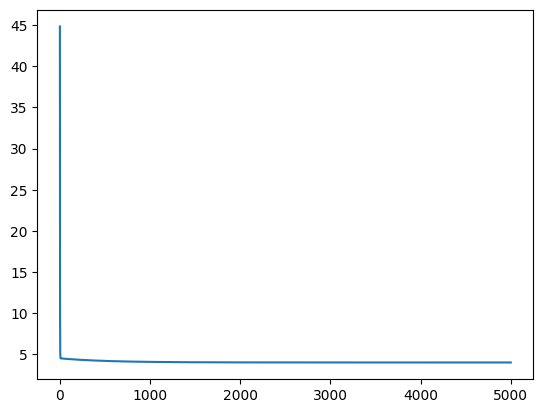

In [78]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

MSE после градиентного спуска:  4.1903709155046345


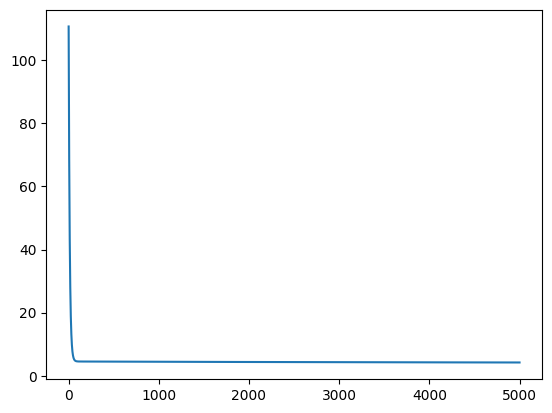

In [79]:
#Запустим цикл градиентного спуска с разными значениями скорости обучения alpha=0.0001, 0.01, 0.1, 1, 10, ..., 
#с различной допукстимой точностью epsylon = 0.001, 0.5, 5, с различным максимальным количеством шагов max_steps
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.0001, epsylon = 0.01, max_steps = 5000)
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
plt.figure()
plt.plot(steps, errors)

Загрузите файл Гиперспектр кукурузы.csv (с помощью pd.read_csv).

1. Вычислите аналитическим путем оценки коэффициентов парной линейной регрессии и постройте ее график.
2. Найдите оценки параметров модели парной лиенйной регрессии с использованием метода градиентного спуска. Постройте график.
3. Оцените качество построенных моделей сравнив на графике обучающую выборку и прогнозы.


In [80]:
#Загрузим файл Гиперспектр кукурузы.csv
gipers = pd.read_csv("Гиперспектр кукурузы.csv",sep=';',decimal=',')
gipers.head()


,wavelength,Spectr
0,397.32,0.02
1,399.54,0.03
2,401.76,0.03
3,403.98,0.05
4,406.20,0.05


In [81]:
#Выделим факторный и результативный признаки
x = gipers['wavelength']
Y = gipers['Spectr']
display(x, Y)


0       397.32
1       399.54
2       401.76
3       403.98
4       406.20
        ...   
268     992.28
269     994.50
270     996.72
271     998.94
272    1001.16
Name: wavelength, Length: 273, dtype: float64

0      0.02
1      0.03
2      0.03
3      0.05
4      0.05
       ... 
268    0.49
269    0.48
270    0.57
271    0.58
272    0.58
Name: Spectr, Length: 273, dtype: float64

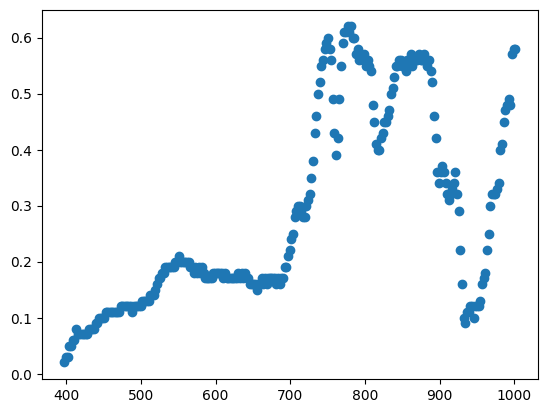

In [82]:
#Изобразим их на графике
plt.figure()
plt.scatter(x, Y)
plt.show()


In [83]:
#Вычислим оценки коэффициентов парной линейной регрессии по формулам
a1 = ((x - x.mean())*(Y - Y.mean())).mean()/((x - x.mean())**2).mean()
a0 = Y.mean() - a1*x.mean()
print("Модель линейной регрессии: Y^ = ", a0, " + ", a1, "* x")


Модель линейной регрессии: Y^ =  -0.1834278267811973  +  0.0006681550262486285 * x


In [84]:
#Дадим серию прогнозов Y^ для x от минимального до максимального значения
x_space = np.linspace(x.min(), x.max(), len(x))
print(x_space)
Y_pred = a0 + a1*x_space
print(Y_pred)


[ 397.32  399.54  401.76  403.98  406.2   408.42  410.64  412.86  415.08
  417.3   419.52  421.74  423.96  426.18  428.4   430.62  432.84  435.06
  437.28  439.5   441.72  443.94  446.16  448.38  450.6   452.82  455.04
  457.26  459.48  461.7   463.92  466.14  468.36  470.58  472.8   475.02
  477.24  479.46  481.68  483.9   486.12  488.34  490.56  492.78  495.
  497.22  499.44  501.66  503.88  506.1   508.32  510.54  512.76  514.98
  517.2   519.42  521.64  523.86  526.08  528.3   530.52  532.74  534.96
  537.18  539.4   541.62  543.84  546.06  548.28  550.5   552.72  554.94
  557.16  559.38  561.6   563.82  566.04  568.26  570.48  572.7   574.92
  577.14  579.36  581.58  583.8   586.02  588.24  590.46  592.68  594.9
  597.12  599.34  601.56  603.78  606.    608.22  610.44  612.66  614.88
  617.1   619.32  621.54  623.76  625.98  628.2   630.42  632.64  634.86
  637.08  639.3   641.52  643.74  645.96  648.18  650.4   652.62  654.84
  657.06  659.28  661.5   663.72  665.94  668.16  670.

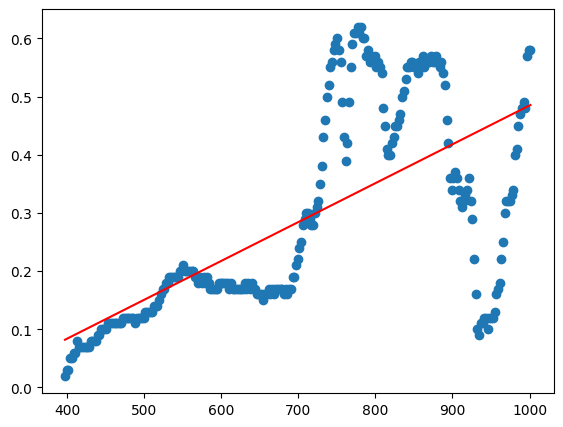

In [85]:
#Изобразим на графике исходные данные и прогнозы 
fig  = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')


In [86]:
#Найдем оценки параметров модели парной линейной регрессии с использованием метода градиентного спуска
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.000001, epsylon = 0.01, max_steps = 5000)


/Users/singularity/PycharmProjects/ML_Methods/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


MSE после градиентного спуска:  nan


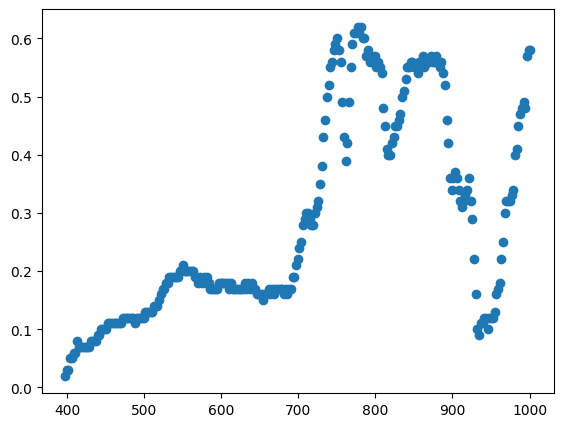

In [87]:
#Выведем график прогнозов и вычислим MSE
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')


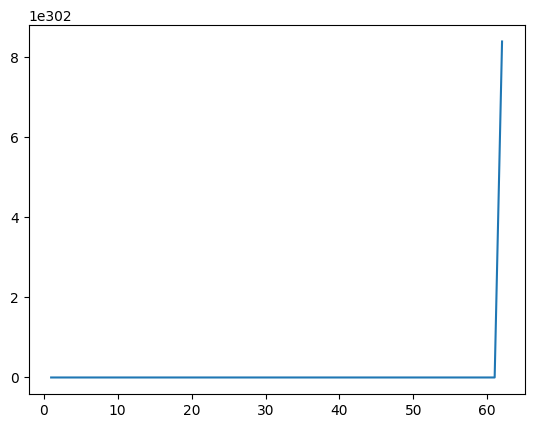

In [88]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)


MSE аналитической модели:  0.017684114628301398
MSE модели, найденной градиентным спуском:  nan


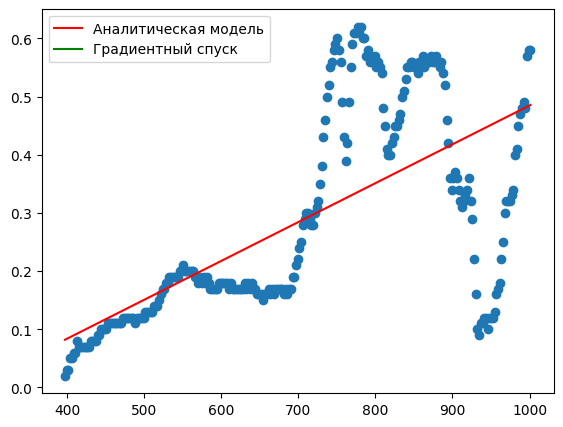

In [89]:
#Сравним качество построенных моделей
Y_pred_analytical = a0 + a1*x
Y_pred_gradient = regr.predict(x)

print("MSE аналитической модели: ", ((Y - Y_pred_analytical)**2).mean())
print("MSE модели, найденной градиентным спуском: ", regr.MSE(x, Y))

fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x, Y_pred_analytical, 'r', label='Аналитическая модель')
ax.plot(x, Y_pred_gradient, 'g', label='Градиентный спуск')
ax.legend()
